## Loading packages

In [1]:
import pandas as pd  # used for data handling
import plotly.io as pio  # used to set the default plotly renderer
import seaborn as sns  # used for statistical data visualization

pio.renderers.default = "notebook"  # set the default plotly renderer to "notebook" (necessary for quarto to render the plots)

## Loading the dataset

The dataset was released alongside the simulated machine at @{ehrensperger_livemachine2026}, but you can also clone the repository directly from [GitHub](https://github.com/noxthot/industrial_datascience_live_machine/tree/v1.0.0).
In this section, we will look at the provided `csv` files.

In [2]:
df_machinedata = pd.read_csv(
    "https://raw.githubusercontent.com/noxthot/industrial_datascience_live_machine/refs/tags/v1.0.0/data/simulated_opcua_machinedata.csv"
)
df_postinspection = pd.read_csv(
    "https://raw.githubusercontent.com/noxthot/industrial_datascience_live_machine/refs/tags/v1.0.0/data/simulated_opcua_postinspection.csv"
)

### Data integrity check

In [3]:
df_machinedata

,Air temperature [K],Attached Weight [mg],Position x [mm],Position y [mm],Process step,Process temperature [K],Speed [mm/s],Speed next [mm/s],timestamp,cycle
0,24.755379,0.000000,191.828040,7.503227,0,30.385614,100.000000,0.000000,2026-01-08T13:37:00,1
1,25.215286,223.987527,191.828040,7.503227,1,31.615630,0.000000,34.752639,2026-01-08T13:37:01.505090,1
2,24.666009,223.987527,150.000000,150.000000,2,31.998852,34.752639,0.000000,2026-01-08T13:37:02.025090,1
3,25.115265,0.000000,150.000000,150.000000,3,33.046526,0.000000,100.000000,2026-01-08T13:37:06.318405,1
4,25.129309,0.000000,7.960791,59.651295,0,33.194048,100.000000,0.000000,2026-01-08T13:37:06.338405,2
...,...,...,...,...,...,...,...,...,...,...
99995,8.068273,0.000000,150.000000,150.000000,3,17.642248,0.000000,100.000000,2026-01-09T21:57:12.230277,24999
99996,10.301384,0.000000,273.977920,126.801859,0,16.803874,100.000000,0.000000,2026-01-09T21:57:12.250277,25000
99997,9.924715,193.867063,273.977920,126.801859,1,16.295092,0.000000,27.812182,2026-01-09T21:57:13.531573,25000
99998,9.452700,193.867063,150.000000,150.000000,2,16.074561,27.812182,0.000000,2026-01-09T21:57:14.051573,25000


In [4]:
df_postinspection

,cycle,error_x,error_y
0,1,-0.192236,0.654895
1,2,1.285577,0.817733
2,3,-0.456091,0.163004
3,4,-1.734704,-0.624146
4,5,-0.496285,0.494395
...,...,...,...
24995,24996,1.080388,2.691526
24996,24997,-0.566057,-0.794911
24997,24998,-0.580030,0.738004
24998,24999,0.773854,-1.404837


In [5]:
df = df_machinedata.merge(df_postinspection, on="cycle", how="left")
df

,Air temperature [K],Attached Weight [mg],Position x [mm],Position y [mm],Process step,Process temperature [K],Speed [mm/s],Speed next [mm/s],timestamp,cycle,error_x,error_y
0,24.755379,0.000000,191.828040,7.503227,0,30.385614,100.000000,0.000000,2026-01-08T13:37:00,1,-0.192236,0.654895
1,25.215286,223.987527,191.828040,7.503227,1,31.615630,0.000000,34.752639,2026-01-08T13:37:01.505090,1,-0.192236,0.654895
2,24.666009,223.987527,150.000000,150.000000,2,31.998852,34.752639,0.000000,2026-01-08T13:37:02.025090,1,-0.192236,0.654895
3,25.115265,0.000000,150.000000,150.000000,3,33.046526,0.000000,100.000000,2026-01-08T13:37:06.318405,1,-0.192236,0.654895
4,25.129309,0.000000,7.960791,59.651295,0,33.194048,100.000000,0.000000,2026-01-08T13:37:06.338405,2,1.285577,0.817733
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,8.068273,0.000000,150.000000,150.000000,3,17.642248,0.000000,100.000000,2026-01-09T21:57:12.230277,24999,0.773854,-1.404837
99996,10.301384,0.000000,273.977920,126.801859,0,16.803874,100.000000,0.000000,2026-01-09T21:57:12.250277,25000,-0.842577,0.157659
99997,9.924715,193.867063,273.977920,126.801859,1,16.295092,0.000000,27.812182,2026-01-09T21:57:13.531573,25000,-0.842577,0.157659
99998,9.452700,193.867063,150.000000,150.000000,2,16.074561,27.812182,0.000000,2026-01-09T21:57:14.051573,25000,-0.842577,0.157659


## Error Visualization

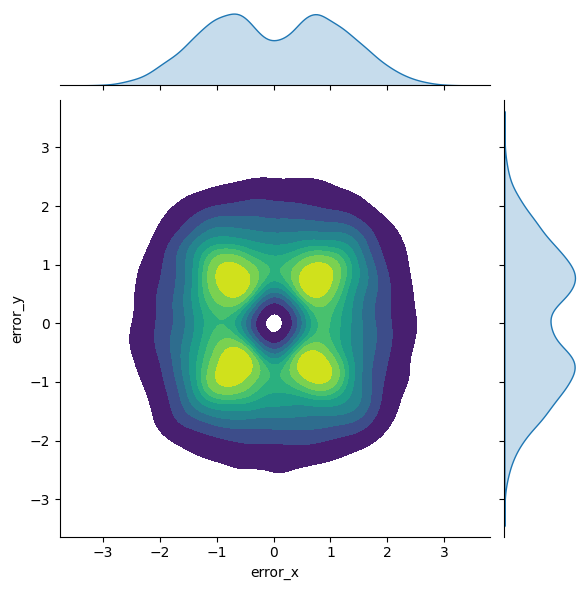

In [6]:
sns.jointplot(
    data=df_postinspection,
    x="error_x",
    y="error_y",
    kind="kde",
    fill=True,
    cmap="viridis",
)

This is a rather interesting error distribution.

## Next Steps

@{sec-act3-selfstudy2} will guide you through the optimization process aimed at reducing these errors and improving overall process accuracy.